# Лабораторная работа 3: Decoder-Only модель (GPT) для генерации текста

**Цель:** Реализовать decoder-only модель (GPT) с использованием слоёв из PyTorch и обучить её на датасете TinyStories для генерации продолжения историй.

## 1. Загрузка библиотек и настройка окружения

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
import math
import matplotlib.pyplot as plt

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cuda


## 2. Загрузка датасета TinyStories

In [ ]:
# Загружаем датасет TinyStories с Hugging Face
print("Загрузка датасета TinyStories...")
dataset = load_dataset('roneneldan/TinyStories', split='train[:100000]')
test_dataset = load_dataset('roneneldan/TinyStories', split='validation[:10000]')

print(f"Размер обучающей выборки: {len(dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"\nПример истории:\n{dataset[0]['text'][:200]}...")

Загрузка датасета TinyStories...
Размер обучающей выборки: 100000
Размер тестовой выборки: 10000

Пример истории:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on...


## 3. Токенизация и предобработка данных

In [79]:
class SimpleTokenizer:
    """Простой токенизатор на уровне слов"""
    def __init__(self, vocab_size=5000):
        self.vocab_size = vocab_size
        self.token2idx = {}
        self.idx2token = {}
        self.special_tokens = {
            '<PAD>': 0,     # Заполнение коротких последовательностей
            '<UNK>': 1,     # Неизвестное слово (не входит в словарь)
            '<START>': 2,   # Начало истории
            '<END>': 3      # Конец истории
        }
        
    def build_vocab(self, texts):
        """Строит словарь на основе частотности токенов"""
        # Подсчет частот токенов
        counter = Counter()
        for text in texts:
            tokens = self._tokenize(text)
            counter.update(tokens)
        
        # Добавляем специальные токены
        self.token2idx = self.special_tokens.copy()
        
        # Добавляем наиболее частотные токены
        most_common = counter.most_common(self.vocab_size - len(self.special_tokens))
        for idx, (token, _) in enumerate(most_common, start=len(self.special_tokens)):
            self.token2idx[token] = idx
        
        self.idx2token = {idx: token for token, idx in self.token2idx.items()}
        print(f"Размер словаря: {len(self.token2idx)}")
        
    def _tokenize(self, text):
        """Простая токенизация: приведение к нижнему регистру и разбиение по пробелам"""
        return text.lower().replace('\n', ' ').split()
    
    def encode(self, text, max_length=None):
        """Преобразование текста в последовательность индексов"""
        tokens = self._tokenize(text)
        indices = [self.token2idx.get(token, self.special_tokens['<UNK>']) for token in tokens]
        
        if max_length is not None:
            if len(indices) > max_length:
                indices = indices[:max_length]
            else:
                indices = indices + [self.special_tokens['<PAD>']] * (max_length - len(indices))
        
        return indices
    
    def decode(self, indices):
        """Преобразование последовательности индексов в текст"""
        tokens = []
        for idx in indices:
            if idx == self.special_tokens['<PAD>']:
                break
            if idx == self.special_tokens['<END>']:
                break
            token = self.idx2token.get(idx, '<UNK>')
            if token not in ['<START>', '<UNK>']:
                tokens.append(token)
        return ' '.join(tokens)

In [80]:
# Создаем и обучаем токенизатор
tokenizer = SimpleTokenizer(vocab_size=7000)
train_texts = [item['text'] for item in dataset]
tokenizer.build_vocab(train_texts)

# Тестируем токенизатор
sample_text = "Once upon a time, there was a little girl."
encoded = tokenizer.encode(sample_text)
decoded = tokenizer.decode(encoded)
print(f"\nОригинальный текст: {sample_text}")
print(f"Закодированный: {encoded}")
print(f"Декодированный: {decoded}")

Размер словаря: 7000

Оригинальный текст: Once upon a time, there was a little girl.
Закодированный: [36, 39, 7, 51, 29, 8, 7, 28, 448]
Декодированный: once upon a time, there was a little girl.


In [81]:
class StoryDataset(Dataset):
    """Датасет для обучения GPT модели"""
    def __init__(self, texts, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.stories = []
        
        # Обрабатываем тексты
        for text in texts:
            # Кодируем текст
            encoded = tokenizer.encode(text, max_length=max_length - 2)  # -2 для <START> и <END>
            
            # Добавляем токены <START> в начало и <END> в конец
            story_with_special_tokens = [tokenizer.special_tokens['<START>']] + encoded + [tokenizer.special_tokens['<END>']]
            
            # Дополняем до max_length если нужно
            if len(story_with_special_tokens) < max_length:
                story_with_special_tokens = story_with_special_tokens + [tokenizer.special_tokens['<PAD>']] * (max_length - len(story_with_special_tokens))
            
            self.stories.append(story_with_special_tokens)
    
    def __len__(self):
        return len(self.stories)
    
    def __getitem__(self, idx):
        # Возвращаем input (все токены кроме последнего) и target (все токены кроме первого)
        story = self.stories[idx]
        input_ids = story[:-1]  # Все кроме последнего токена
        target_ids = story[1:]  # Все кроме первого токена (сдвиг на 1)
        
        return torch.tensor(input_ids, dtype=torch.long), torch.tensor(target_ids, dtype=torch.long)

In [82]:
# Создаем датасеты и загрузчики данных
MAX_LENGTH = 128
BATCH_SIZE = 32  # Уменьшен батч для более стабильного обучения

train_texts = [item['text'] for item in dataset]
test_texts = [item['text'] for item in test_dataset]

train_dataset_obj = StoryDataset(train_texts, tokenizer, max_length=MAX_LENGTH)
test_dataset_obj = StoryDataset(test_texts, tokenizer, max_length=MAX_LENGTH)

train_loader = DataLoader(train_dataset_obj, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset_obj, batch_size=BATCH_SIZE, shuffle=False)

print(f"Количество батчей в train: {len(train_loader)}")
print(f"Количество батчей в test: {len(test_loader)}")

Количество батчей в train: 3125
Количество батчей в test: 313


## 4. Реализация архитектуры Decoder-Only (GPT)

Реализуем все компоненты с нуля без использования `nn.Transformer`

### 4.1 Multi-Head Self-Attention с Causal Mask

In [83]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self-Attention с causal mask для автогрессивной генерации"""
    def __init__(self, embedding_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embedding_dim % num_heads == 0, "embedding_dim должен делиться на num_heads"
        
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads  # Размерность каждой головы
        
        # Линейные проекции для Query, Key, Value
        self.query_projection = nn.Linear(embedding_dim, embedding_dim)
        self.key_projection = nn.Linear(embedding_dim, embedding_dim)
        self.value_projection = nn.Linear(embedding_dim, embedding_dim)
        
        # Финальная проекция после объединения голов
        self.output_projection = nn.Linear(embedding_dim, embedding_dim)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_tensor, mask=None):
        batch_size, sequence_length, embedding_dim = input_tensor.shape
        
        # Создаем Query, Key, Value проекции из входа
        query = self.query_projection(input_tensor)  # [batch, seq_len, embedding_dim]
        key = self.key_projection(input_tensor)
        value = self.value_projection(input_tensor)
        
        # Разделяем на несколько голов: [batch, seq_len, num_heads, head_dim]
        query = query.view(batch_size, sequence_length, self.num_heads, self.head_dim)
        key = key.view(batch_size, sequence_length, self.num_heads, self.head_dim)
        value = value.view(batch_size, sequence_length, self.num_heads, self.head_dim)
        
        # Переставляем размерности для параллельной обработки голов: [batch, num_heads, seq_len, head_dim]
        query = query.transpose(1, 2)
        key = key.transpose(1, 2)
        value = value.transpose(1, 2)
        
        # Scaled Dot-Product Attention: вычисляем насколько каждый токен "похож" на другие
        # attention_scores = (Query · Key^T) / sqrt(head_dim)
        attention_scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(self.head_dim)
        
        # Применяем causal mask: запрещаем модели смотреть в будущее
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))
        
        # Применяем softmax для получения весов внимания (вероятностей)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Взвешенная сумма значений (Value) с весами внимания
        output = torch.matmul(attention_weights, value)  # [batch, num_heads, seq_len, head_dim]
        
        # Объединяем головы обратно
        output = output.transpose(1, 2).contiguous()  # [batch, seq_len, num_heads, head_dim]
        output = output.view(batch_size, sequence_length, embedding_dim)  # [batch, seq_len, embedding_dim]
        
        # Финальная проекция
        output = self.output_projection(output)
        
        return output

### 4.2 Feed-Forward Network

In [84]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network - применяется независимо к каждой позиции"""
    def __init__(self, embedding_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.first_linear = nn.Linear(embedding_dim, hidden_dim)
        self.second_linear = nn.Linear(hidden_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_tensor):
        # input_tensor: [batch, seq_len, embedding_dim]
        # Расширяем размерность через первый линейный слой
        hidden = self.first_linear(input_tensor)
        # Применяем GELU активацию (более плавная чем ReLU, лучше для Transformer)
        hidden = F.gelu(hidden)
        hidden = self.dropout(hidden)
        # Возвращаем к исходной размерности
        output = self.second_linear(hidden)
        return output

### 4.3 Decoder Block

In [85]:
class DecoderBlock(nn.Module):
    """Один блок декодера Transformer"""
    def __init__(self, embedding_dim, num_heads, feedforward_dim, dropout=0.1):
        super().__init__()
        
        # Multi-Head Self-Attention механизм
        self.attention = MultiHeadSelfAttention(embedding_dim, num_heads, dropout)
        
        # Feed-Forward Network
        self.feed_forward = FeedForward(embedding_dim, feedforward_dim, dropout)
        
        # Layer Normalization для стабилизации обучения
        self.layer_norm_1 = nn.LayerNorm(embedding_dim)
        self.layer_norm_2 = nn.LayerNorm(embedding_dim)
        
        # Dropout для регуляризации
        self.dropout_1 = nn.Dropout(dropout)
        self.dropout_2 = nn.Dropout(dropout)
        
    def forward(self, input_tensor, mask=None):
        # Self-Attention с residual connection (пропускаем вход напрямую к выходу)
        attention_output = self.attention(input_tensor, mask)
        # Residual connection: добавляем исходный вход к результату attention
        input_tensor = input_tensor + self.dropout_1(attention_output)
        # Нормализуем для стабильности
        input_tensor = self.layer_norm_1(input_tensor)
        
        # Feed-Forward с residual connection
        feedforward_output = self.feed_forward(input_tensor)
        # Снова residual connection
        input_tensor = input_tensor + self.dropout_2(feedforward_output)
        # Снова нормализация
        input_tensor = self.layer_norm_2(input_tensor)
        
        return input_tensor

### 4.4 Полная GPT модель

In [86]:
class GPTModel(nn.Module):
    """Decoder-Only модель (GPT)"""
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, feedforward_dim, max_sequence_length, dropout=0.1):
        super().__init__()
        
        self.embedding_dim = embedding_dim
        self.max_sequence_length = max_sequence_length
        
        # Token Embedding: преобразует индекс токена в вектор
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Positional Embedding: добавляет информацию о позиции токена в последовательности
        self.position_embedding = nn.Embedding(max_sequence_length, embedding_dim)
        
        # Dropout для регуляризации embeddings
        self.dropout = nn.Dropout(dropout)
        
        # Стек из нескольких decoder blocks
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(embedding_dim, num_heads, feedforward_dim, dropout) for _ in range(num_layers)
        ])
        
        # Финальная нормализация перед предсказанием
        self.final_layer_norm = nn.LayerNorm(embedding_dim)
        
        # Language Modeling Head: преобразует embeddings обратно в вероятности токенов
        self.language_model_head = nn.Linear(embedding_dim, vocab_size)
        
        # Инициализация весов для стабильного обучения
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        """Инициализация весов сети"""
        if isinstance(module, nn.Linear):
            # Инициализируем веса линейных слоев нормальным распределением
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Инициализируем embeddings
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            # Инициализируем Layer Normalization
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)
    
    def create_causal_mask(self, sequence_length, device):
        """
        Создает causal mask для автогрессивной генерации.
        Маска не позволяет токену "видеть" будущие токены при обучении.
        """
        # Создаем нижнетреугольную матрицу (1 = видим, 0 = не видим)
        mask = torch.tril(torch.ones(sequence_length, sequence_length, device=device))
        # Добавляем размерности для batch и heads: [1, 1, seq_len, seq_len]
        mask = mask.unsqueeze(0).unsqueeze(0)
        return mask
    
    def forward(self, input_token_ids):
        batch_size, sequence_length = input_token_ids.shape
        device = input_token_ids.device
        
        # Получаем token embeddings для каждого токена
        token_embeddings = self.token_embedding(input_token_ids)  # [batch, seq_len, embedding_dim]
        
        # Создаем позиционные индексы для каждого токена
        position_indices = torch.arange(0, sequence_length, device=device).unsqueeze(0).expand(batch_size, sequence_length)
        position_embeddings = self.position_embedding(position_indices)
        
        # Комбинируем token и positional embeddings
        combined_embeddings = token_embeddings + position_embeddings
        combined_embeddings = self.dropout(combined_embeddings)
        
        # Создаем causal mask чтобы модель не видела будущее
        causal_mask = self.create_causal_mask(sequence_length, device)
        
        # Последовательно пропускаем через все decoder blocks
        hidden_states = combined_embeddings
        for decoder_block in self.decoder_blocks:
            hidden_states = decoder_block(hidden_states, causal_mask)
        
        # Финальная нормализация
        hidden_states = self.final_layer_norm(hidden_states)
        
        # Преобразуем скрытые состояния в логиты (оценки вероятности) для каждого токена
        logits = self.language_model_head(hidden_states)  # [batch, seq_len, vocab_size]
        
        return logits

In [87]:
# Гиперпараметры модели
VOCAB_SIZE = len(tokenizer.token2idx)
EMBEDDING_DIM = 256      # Размерность векторных представлений
NUM_HEADS = 4            # Количество голов в Multi-Head Attention
NUM_LAYERS = 4           # Количество decoder блоков (глубина модели)
FEEDFORWARD_DIM = 1024   # Размерность скрытого слоя в Feed-Forward сети
MAX_SEQUENCE_LENGTH = MAX_LENGTH - 1  # Максимальная длина последовательности
DROPOUT = 0.1            # Вероятность dropout для регуляризации

# Создаем модель
model = GPTModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    feedforward_dim=FEEDFORWARD_DIM,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    dropout=DROPOUT
).to(device)

# Считаем количество параметров
total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

print(f"Модель создана!")
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Модель создана!
Всего параметров: 6,783,064
Обучаемых параметров: 6,783,064


## 5. Обучение модели

In [88]:
from torch.nn.utils import clip_grad_norm_

def train_epoch(model, dataloader, optimizer, criterion, device):
    """Обучение модели на одной эпохе"""
    model.train()  # Переключаем модель в режим обучения
    total_loss = 0
    
    for batch_idx, (input_token_ids, target_token_ids) in enumerate(dataloader):
        # Переносим данные на GPU/CPU
        input_token_ids = input_token_ids.to(device)
        target_token_ids = target_token_ids.to(device)
        
        # Обнуляем градиенты перед новым шагом
        optimizer.zero_grad()
        
        # Forward pass: получаем предсказания модели
        logits = model(input_token_ids)  # [batch, seq_len, vocab_size]
        
        # Вычисление функции потерь
        # Изменяем форму для CrossEntropyLoss: [batch*seq_len, vocab_size] и [batch*seq_len]
        loss = criterion(logits.view(-1, logits.size(-1)), target_token_ids.view(-1))
        
        # Backward pass: вычисляем градиенты
        loss.backward()
        
        # Gradient clipping: ограничиваем норму градиентов для стабильности обучения
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Обновляем веса модели
        optimizer.step()
        
        total_loss += loss.item()
        
        # Выводим прогресс каждые 100 батчей
        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}")
    
    # Возвращаем среднюю ошибку за эпоху
    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    """Оценка модели на тестовой выборке"""
    model.eval()  # Переключаем модель в режим оценки (отключает dropout и т.д.)
    total_loss = 0
    
    with torch.no_grad():  # Отключаем вычисление градиентов для экономии памяти
        for input_token_ids, target_token_ids in dataloader:
            input_token_ids = input_token_ids.to(device)
            target_token_ids = target_token_ids.to(device)
            
            logits = model(input_token_ids)
            loss = criterion(logits.view(-1, logits.size(-1)), target_token_ids.view(-1))
            
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

In [89]:
# Настройка обучения
EPOCHS = 7
LEARNING_RATE = 3e-4

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.special_tokens['<PAD>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Для отслеживания прогресса
train_losses = []
val_losses = []

print("Начало обучения...\n")

for epoch in range(EPOCHS):
    print(f"Эпоха {epoch + 1}/{EPOCHS}")
    
    # Обучение
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    
    # Валидация
    val_loss = evaluate(model, test_loader, criterion, device)
    val_losses.append(val_loss)
    
    print(f"Эпоха {epoch + 1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}\n")

print("Обучение завершено!")

Начало обучения...

Эпоха 1/7
  Batch 0/3125, Loss: 8.9177
  Batch 100/3125, Loss: 4.9046
  Batch 200/3125, Loss: 4.3603
  Batch 300/3125, Loss: 4.1936
  Batch 400/3125, Loss: 3.9923
  Batch 500/3125, Loss: 3.9562
  Batch 600/3125, Loss: 3.7894
  Batch 700/3125, Loss: 3.7272
  Batch 800/3125, Loss: 3.6620
  Batch 900/3125, Loss: 3.6314
  Batch 1000/3125, Loss: 3.4789
  Batch 1100/3125, Loss: 3.4940
  Batch 1200/3125, Loss: 3.5038
  Batch 1300/3125, Loss: 3.4227
  Batch 1400/3125, Loss: 3.3583
  Batch 1500/3125, Loss: 3.2907
  Batch 1600/3125, Loss: 3.1681
  Batch 1700/3125, Loss: 3.2551
  Batch 1800/3125, Loss: 3.1658
  Batch 1900/3125, Loss: 3.0984
  Batch 2000/3125, Loss: 3.1712
  Batch 2100/3125, Loss: 3.2515
  Batch 2200/3125, Loss: 3.0687
  Batch 2300/3125, Loss: 3.0774
  Batch 2400/3125, Loss: 3.0690
  Batch 2500/3125, Loss: 2.9896
  Batch 2600/3125, Loss: 3.1645
  Batch 2700/3125, Loss: 2.9143
  Batch 2800/3125, Loss: 2.9486
  Batch 2900/3125, Loss: 2.8766
  Batch 3000/3125, Los

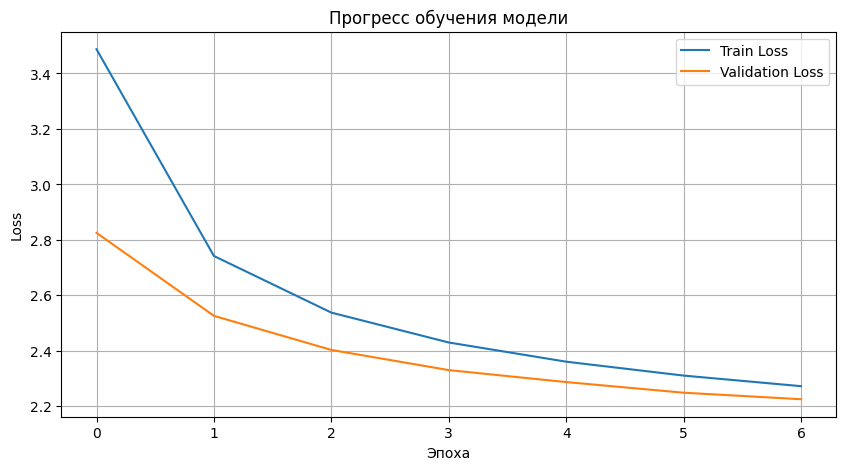

In [90]:
# Визуализация прогресса обучения
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Прогресс обучения модели')
plt.legend()
plt.grid(True)
plt.show()

Предыдущий результат (50тыс на обучение, 10тыс на валидацию, тот же batch_size, то же количество эпох, ещё увеличил количество токенов на выход. Если брать первые разы обучения, было 50тыс/10тыс/64bs/5эпох, loss был выше)

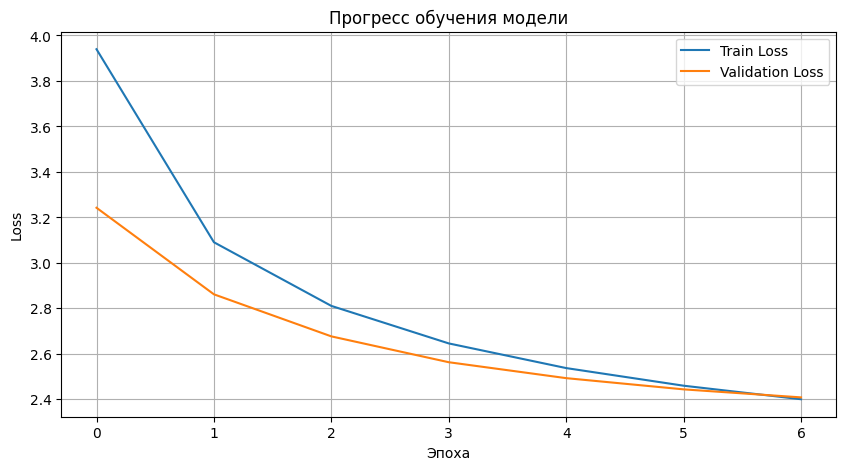

## 6. Генерация текста

In [91]:
def generate_text(model, tokenizer, prompt, max_length=100, temperature=0.8, top_k=50, device='cuda'):
    """
    Генерация текста с использованием модели
    
    Args:
        model: обученная GPT модель
        tokenizer: токенизатор
        prompt: начальный текст для генерации
        max_length: максимальная длина генерируемого текста (в токенах)
        temperature: коэффициент управления случайностью (низкий = предсказуемо, высокий = креативно)
        top_k: количество наиболее вероятных токенов для выбора
        device: устройство для вычислений (cuda или cpu)
    """
    model.eval()
    
    # Кодируем начальный промпт
    input_ids = tokenizer.encode(prompt)
    input_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    generated = input_ids
    
    with torch.no_grad():
        for _ in range(max_length):
            # Обрезаем до максимальной длины последовательности если нужно
            if generated.size(1) > model.max_sequence_length:
                input_sequence = generated[:, -model.max_sequence_length:]
            else:
                input_sequence = generated
            
            # Получаем предсказания модели
            logits = model(input_sequence)  # [batch_size, sequence_length, vocab_size]
            
            # Берем предсказание только для последнего токена
            next_token_logits = logits[:, -1, :] / temperature
            
            # Top-k сэмплирование: оставляем только k наиболее вероятных токенов
            if top_k > 0:
                indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                next_token_logits[indices_to_remove] = float('-inf')
            
            # Преобразуем логиты в вероятности и выбираем следующий токен
            probabilities = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)
            
            # Проверяем на конец последовательности
            if next_token.item() == tokenizer.special_tokens['<END>']:
                break
            
            # Добавляем сгенерированный токен к последовательности
            generated = torch.cat([generated, next_token], dim=1)
    
    # Декодируем результат обратно в текст
    generated_text = tokenizer.decode(generated[0].cpu().tolist())
    
    return generated_text

## 7. Тестирование на примерах из test

In [92]:
# Выбираем несколько случайных историй из тестовой выборки
import random

test_samples = random.sample(test_texts, 3)

print("=" * 80)
print("ТЕСТИРОВАНИЕ НА ПРИМЕРАХ ИЗ TEST")
print("=" * 80)

for i, story in enumerate(test_samples, 1):
    # Берем первые несколько слов в качестве промпта
    words = story.split()
    prompt_length = min(10, len(words) // 3)
    prompt = ' '.join(words[:prompt_length])
    
    print(f"\n{'='*80}")
    print(f"ПРИМЕР {i}")
    print(f"{'='*80}")
    print(f"\nПРОМПТ (начало истории):\n{prompt}")
    
    # Генерируем продолжение
    generated = generate_text(
        model, tokenizer, prompt, 
        max_length=150, 
        temperature=0.8, 
        top_k=50, 
        device=device
    )
    
    print(f"\nСГЕНЕРИРОВАННОЕ ПРОДОЛЖЕНИЕ:\n{generated}")
    
    # Показываем оригинальную историю для сравнения
    print(f"\nОРИГИНАЛЬНАЯ ИСТОРИЯ (для сравнения):\n{story[:500]}...")

ТЕСТИРОВАНИЕ НА ПРИМЕРАХ ИЗ TEST

ПРИМЕР 1

ПРОМПТ (начало истории):
Once upon a time, there was a friendly pink dog.

СГЕНЕРИРОВАННОЕ ПРОДОЛЖЕНИЕ:
once upon a time, there was a friendly pink dog. he liked to play in the park. one day, the pink dog saw a little boy. he was scared. he wanted to play with the dog and eat him. the brown dog walked right up to the boy and said, "hi, dog! can i play with you?" the brown dog was happy and started to chase the kids with the dog. the brown dog ran around the park, having fun. but then, he saw a dog. the dog barked at the dog and the dog ran away. the yellow dog chased after the dog. but the big dog was too fast. the dog ran as fast as he could. the brown dog ran and ran, until

ОРИГИНАЛЬНАЯ ИСТОРИЯ (для сравнения):
Once upon a time, there was a friendly pink dog. Her name was Lily and she loved to play. Every day she would set out to have some fun in the sun. One day, Lily said to her owner, "I'm feeling so bored. Could you please set me free 

## 8. Генерация собственных историй

In [93]:
# Собственные промпты для генерации историй
custom_prompts = [
    "Once upon a time, there was a little",
    "One day, a brave",
    "In a magical forest, there lived",
    "A small boy found a",
    "The sun was shining and"
]

print("\n" + "=" * 80)
print("ГЕНЕРАЦИЯ СОБСТВЕННЫХ ИСТОРИЙ")
print("=" * 80)

for i, prompt in enumerate(custom_prompts, 1):
    print(f"\n{'='*80}")
    print(f"ИСТОРИЯ {i}")
    print(f"{'='*80}")
    print(f"\nПРОМПТ: {prompt}")
    
    generated = generate_text(
        model, tokenizer, prompt,
        max_length=100,
        temperature=0.8,
        top_k=40,
        device=device
    )
    
    print(f"\nГЕНЕРАЦИЯ:\n{generated}")


ГЕНЕРАЦИЯ СОБСТВЕННЫХ ИСТОРИЙ

ИСТОРИЯ 1

ПРОМПТ: Once upon a time, there was a little

ГЕНЕРАЦИЯ:
once upon a time, there was a little bear who liked to play in the forest. he was very careful around with his friends and they loved to play together. one day, he found a shiny box made of paper and decided to use it to draw a butterfly. he was very excited to show his friends the when they got there, the little bear showed them to his friends. they all loved it and they showed it to his friends and they all was very happy. the little bear and his friends decided to use the box to draw a picture of the forest and have

ИСТОРИЯ 2

ПРОМПТ: One day, a brave

ГЕНЕРАЦИЯ:
one day, a brave child went out for a walk at home. he could see the most beautiful the child was so excited to explore the world. the child was so excited to see what was inside the when he arrived at the he saw all of his hard he was so excited he jumped out of the sky and admired it. he smiled as he stepped out of the he 

## 9. Интерактивная генерация

In [94]:
# Интерактивная генерация (запустите эту ячейку и введите свой промпт)
print("Введите начало истории (или 'quit' для выхода):")

while True:
    user_prompt = input("\n> ")
    
    if user_prompt.lower() == 'quit':
        break
    
    if not user_prompt.strip():
        print("Пожалуйста, введите текст.")
        continue
    
    print("\nГенерация...")
    generated = generate_text(
        model, tokenizer, user_prompt,
        max_length=100,
        temperature=0.8,
        top_k=50,
        device=device
    )
    
    print(f"\nСгенерированная история:\n{generated}")

Введите начало истории (или 'quit' для выхода):


## 10. Выводы

Модель работает, к сожалению при последнем обучении она переобучилась, стала просто запоминать частые слова, уменьшилась генерация разнообразного текста.